# 04c: Structural State-Space Model (Unobserved Components)

## Objective
Replace the previous Random Forest model with a **structural / state‑space model**
for weekly bed occupancy forecasting, using the same curated exogenous set as
the ARIMAX/SARIMAX notebook and a common evaluation + rolling time‑series
cross‑validation framework.

## Model
- `UnobservedComponents` with:
  - Local linear trend
  - 52‑week seasonal component
  - Regression on curated exogenous features (flu, weather, cyclical encodings, lagged KPIs)

## Outputs
- Point‑forecast test metrics: `MAE`, `RMSE`, `MAPE`, `Bias`, `n`
  saved to `structural_evaluation.csv` (rows: `structural_train`, `structural_test`)
- Forecast CSV: `structural_forecast.csv` with actual vs predicted bed occupancy
- Visualization: `structural_model_results.png` with forecast plots and residual analysis

## Project & Environment Configuration

In [13]:
import os
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.structural import UnobservedComponents

warnings.filterwarnings("ignore")

# Shared evaluation utilities (metrics) and external time-series CV splitter
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error


def calculate_all_metrics(actual: np.ndarray, predicted: np.ndarray) -> dict:
    """Compute core metrics (no R²)."""
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    nz_mask = actual != 0
    mape = np.nan if nz_mask.sum() == 0 else float(np.mean(np.abs((actual[nz_mask] - predicted[nz_mask]) / actual[nz_mask])) * 100)
    bias = float(np.mean(predicted - actual))
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "Bias": bias}

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Google Colab / local paths (mirrors other notebooks)
DRIVE_MOUNTED = False
DRIVE_DATA_PROCESSED = None
DRIVE_MODELS_PATH = None
DRIVE_RESULTS_PATH = None

try:
    from google.colab import drive  # type: ignore

    if os.path.exists("/content/drive"):
        DRIVE_MOUNTED = True
        print("✓ Google Drive already mounted")
    else:
        print("📁 Mounting Google Drive...")
        drive.mount("/content/drive")
        DRIVE_MOUNTED = True
        print("✓ Google Drive mounted successfully")

    if DRIVE_MOUNTED:
        DRIVE_ROOT = "/content/drive/MyDrive/hospital_occupancy_forecasting"
        DRIVE_DATA_PROCESSED = os.path.join(DRIVE_ROOT, "data", "processed")
        DRIVE_MODELS_PATH = os.path.join(DRIVE_ROOT, "models")
        DRIVE_RESULTS_PATH = os.path.join(
            DRIVE_ROOT, "results", "visualizations", "model_development"
        )
        os.makedirs(DRIVE_DATA_PROCESSED, exist_ok=True)
        os.makedirs(DRIVE_MODELS_PATH, exist_ok=True)
        os.makedirs(DRIVE_RESULTS_PATH, exist_ok=True)
        print(f"✓ Google Drive paths configured: {DRIVE_ROOT}")
except ImportError:
    print("ℹ️  Not running in Google Colab (will only check local paths)")
except Exception as e:
    print(f"⚠️  Could not mount Google Drive: {e}")
    print("   Will continue with local paths only")

# Local project paths (for Colab or local execution)
PROJECT_ROOT = "/content/hospital_occupancy_forecasting"
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
DATA_RAW = os.path.join(DATA_DIR, "raw")
DATA_PROCESSED = os.path.join(DATA_DIR, "processed")
MODELS_PATH = os.path.join(PROJECT_ROOT, "models")
RESULTS_PATH = os.path.join(
    PROJECT_ROOT, "results", "visualizations", "model_development"
)

for path in [DATA_RAW, DATA_PROCESSED, MODELS_PATH, RESULTS_PATH]:
    os.makedirs(path, exist_ok=True)


def save_file(data, filename, local_path, drive_path=None, **kwargs):
    """Save file to both local and Google Drive (if available)."""
    local_file = os.path.join(local_path, filename)
    if isinstance(data, pd.DataFrame):
        data.to_csv(local_file, **kwargs)
    elif isinstance(data, (dict, list)) and filename.endswith(".json"):
        import json

        with open(local_file, "w") as f:
            json.dump(data, f, **kwargs)
    elif filename.endswith(".pkl"):
        import pickle

        with open(local_file, "wb") as f:
            pickle.dump(data, f)
    else:
        with open(local_file, "w") as f:
            f.write(str(data))
    print(f"✓ Saved to local: {local_file}")

    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            if isinstance(data, pd.DataFrame):
                data.to_csv(drive_file, **kwargs)
            elif isinstance(data, (dict, list)) and filename.endswith(".json"):
                import json

                with open(drive_file, "w") as f:
                    json.dump(data, f, **kwargs)
            elif filename.endswith(".pkl"):
                import pickle

                with open(drive_file, "wb") as f:
                    pickle.dump(data, f)
            else:
                with open(drive_file, "w") as f:
                    f.write(str(data))
            print(f"✓ Saved to Google Drive: {drive_file}")
        except Exception as e:
            print(f"⚠️  Could not save to Google Drive: {e}")


def save_plot(fig, filename, local_path, drive_path=None, **kwargs):
    """Save plot to both local and Google Drive."""
    local_file = os.path.join(local_path, filename)
    fig.savefig(local_file, **kwargs)
    print(f"✓ Saved plot to local: {local_file}")

    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            fig.savefig(drive_file, **kwargs)
            print(f"✓ Saved plot to Google Drive: {drive_file}")
        except Exception as e:
            print(f"⚠️  Could not save plot to Google Drive: {e}")


def load_file(filename, local_path, drive_path=None):
    """Load file from local or Google Drive (local priority)."""
    local_file = os.path.join(local_path, filename)
    if os.path.exists(local_file):
        if filename.endswith(".csv"):
            return pd.read_csv(local_file, index_col=0, parse_dates=True)
        elif filename.endswith(".pkl"):
            import pickle

            with open(local_file, "rb") as f:
                return pickle.load(f)
        elif filename.endswith(".json"):
            import json

            with open(local_file, "r") as f:
                return json.load(f)
    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            if os.path.exists(drive_file):
                if filename.endswith(".csv"):
                    return pd.read_csv(drive_file, index_col=0, parse_dates=True)
                elif filename.endswith(".pkl"):
                    import pickle

                    with open(drive_file, "rb") as f:
                        return pickle.load(f)
                elif filename.endswith(".json"):
                    import json

                    with open(drive_file, "r") as f:
                        return json.load(f)
        except Exception as e:
            print(f"⚠️  Could not load from Google Drive: {e}")
    return None

✓ Google Drive already mounted
✓ Google Drive paths configured: /content/drive/MyDrive/hospital_occupancy_forecasting


## Configuration & Feature Setup (from 03_feature_engineering)

In [14]:
import json

DATA_FREQUENCY = "weekly"
WEEKS_PER_YEAR = 52
FORECAST_HORIZON = 4  # 4-week horizon for evaluation and CV
TRAIN_TEST_SPLIT = 0.8

# Rolling window configuration for SSM - Hybrid Retraining
SSM_WINDOW_SIZE = 2  # Smaller windows (2 weeks) for more frequent updates
SSM_BASE_RETRAIN_FREQUENCY = 2  # Retrain every 2 weeks
SSM_ERROR_THRESHOLD = 1.3  # Retrain if error > 1.3x historical average
SSM_EARLY_RETRAIN_THRESHOLD = 2  # Minimum 2 weeks between error-based retrains

FEATURE_CONFIG = None
feature_config_paths = [
    os.path.join(DATA_PROCESSED, "feature_config.json"),
    os.path.join(DRIVE_DATA_PROCESSED, "feature_config.json")
    if DRIVE_DATA_PROCESSED
    else None,
]

for config_path in feature_config_paths:
    if config_path and os.path.exists(config_path):
        try:
            with open(config_path, "r") as f:
                FEATURE_CONFIG = json.load(f)
            print(f"✓ Loaded CENTRALIZED feature config from: {config_path}")
            break
        except Exception as e:
            print(f"⚠️ Error loading {config_path}: {e}")

if FEATURE_CONFIG:
    ARIMAX_CONFIG = FEATURE_CONFIG.get("arimax", {})
    ARIMAX_EXOG_CONFIG = ARIMAX_CONFIG.get("exogenous", [])
    ARIMAX_CYCLICAL_CONFIG = ARIMAX_CONFIG.get("cyclical", [])
    ARIMAX_KPI_LAGGED_CONFIG = ARIMAX_CONFIG.get("kpi_lagged", [])
    print("📋 ARIMAX feature configuration:")
    print(f"  Exogenous: {ARIMAX_EXOG_CONFIG}")
    print(f"  Cyclical:  {ARIMAX_CYCLICAL_CONFIG}")
    print(f"  KPI lagged: {ARIMAX_KPI_LAGGED_CONFIG}")
else:
    print("⚠️  Feature config not found, using defaults. Run 03_feature_engineering.ipynb first.")
    ARIMAX_EXOG_CONFIG = ["ili", "temp_min", "holidays_in_week"]
    ARIMAX_CYCLICAL_CONFIG = [
        "quarter_sin",
        "quarter_cos",
        "day_of_year_sin",
        "day_of_year_cos",
    ]
    ARIMAX_KPI_LAGGED_CONFIG = ["covid_patient_pct_lag1"]

✓ Loaded CENTRALIZED feature config from: /content/drive/MyDrive/hospital_occupancy_forecasting/data/processed/feature_config.json
📋 ARIMAX feature configuration:
  Exogenous: ['ili_lag_1', 'temp_min_lag_1', 'holidays_in_week']
  Cyclical:  ['quarter_sin', 'quarter_cos', 'day_of_year_sin', 'day_of_year_cos']
  KPI lagged: ['covid_patient_pct_lag1']


## Load Weekly Bed Occupancy & Exogenous Features

In [15]:
print("=" * 70)
print("LOADING WEEKLY BED OCCUPANCY WITH FEATURES")
print("=" * 70)

# Prefer ARIMAX-specific features (curated) but fall back to full occupancy_with_features
data = load_file("features_for_arimax.csv", DATA_PROCESSED, DRIVE_DATA_PROCESSED)

if data is None:
    data = load_file("occupancy_with_features.csv", DATA_PROCESSED, DRIVE_DATA_PROCESSED)

if data is not None:
    if "bed_occupancy" in data.columns:
        target_col = "bed_occupancy"
    else:
        occupancy_cols = [
            c
            for c in data.columns
            if "occupancy" in c.lower() or "bed" in c.lower()
        ]
        if occupancy_cols:
            target_col = occupancy_cols[0]
            print(f"⚠️  Using {target_col} as target (bed_occupancy not found explicitly)")
        else:
            target_col = data.columns[0]
            print(
                f"⚠️  Using first column as target: {target_col} "
                "(no obvious bed_occupancy column)"
            )

    target_series = data[target_col].copy()
    print(f"\n✓ Loaded: {len(data)} weeks")
    print(f"  Date range: {data.index.min().date()} to {data.index.max().date()}")
    print(f"  Target: {target_col}")
    print("\nTarget statistics:")
    print(target_series.describe())

    # Build curated exogenous matrix
    exog_candidates = data.drop(columns=[target_col])
    curated_exog_names = [
        c
        for c in (
            ARIMAX_CYCLICAL_CONFIG + ARIMAX_EXOG_CONFIG + ARIMAX_KPI_LAGGED_CONFIG
        )
        if c in exog_candidates.columns
    ]

    if curated_exog_names:
        print(
            f"\n✓ Using {len(curated_exog_names)} exogenous regressors for structural model:"
        )
        print(f"  {curated_exog_names}")
        exog_all = (
            exog_candidates[curated_exog_names].copy().ffill().bfill().fillna(0.0)
        )
    else:
        print(
            "\n⚠️  No curated ARIMAX exogenous features available; "
            "structural model will be univariate."
        )
        exog_all = None
else:
    print("❌ Could not load weekly occupancy features.")
    print("   Expected one of: features_for_arimax.csv, occupancy_with_features.csv")
    target_series = pd.Series(dtype=float)
    exog_all = None

LOADING WEEKLY BED OCCUPANCY WITH FEATURES

✓ Loaded: 197 weeks
  Date range: 2020-07-19 to 2024-04-21
  Target: bed_occupancy

Target statistics:
count     197.000000
mean     2254.367005
std       136.466602
min      1882.000000
25%      2184.700000
50%      2269.400000
75%      2353.400000
max      2510.700000
Name: bed_occupancy, dtype: float64

✓ Using 6 exogenous regressors for structural model:
  ['quarter_sin', 'quarter_cos', 'day_of_year_sin', 'day_of_year_cos', 'ili_lag_1', 'holidays_in_week']


## Train–Test Split


Train set: 157 weeks (2020-07-19 to 2023-07-16)
Test set:  40 weeks (2023-07-23 to 2024-04-21)
Train/Test split: 157/40 = 80.0%
✓ Saved plot to local: /content/hospital_occupancy_forecasting/results/visualizations/model_development/ssm_train_test_split.png
✓ Saved plot to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/results/visualizations/model_development/ssm_train_test_split.png


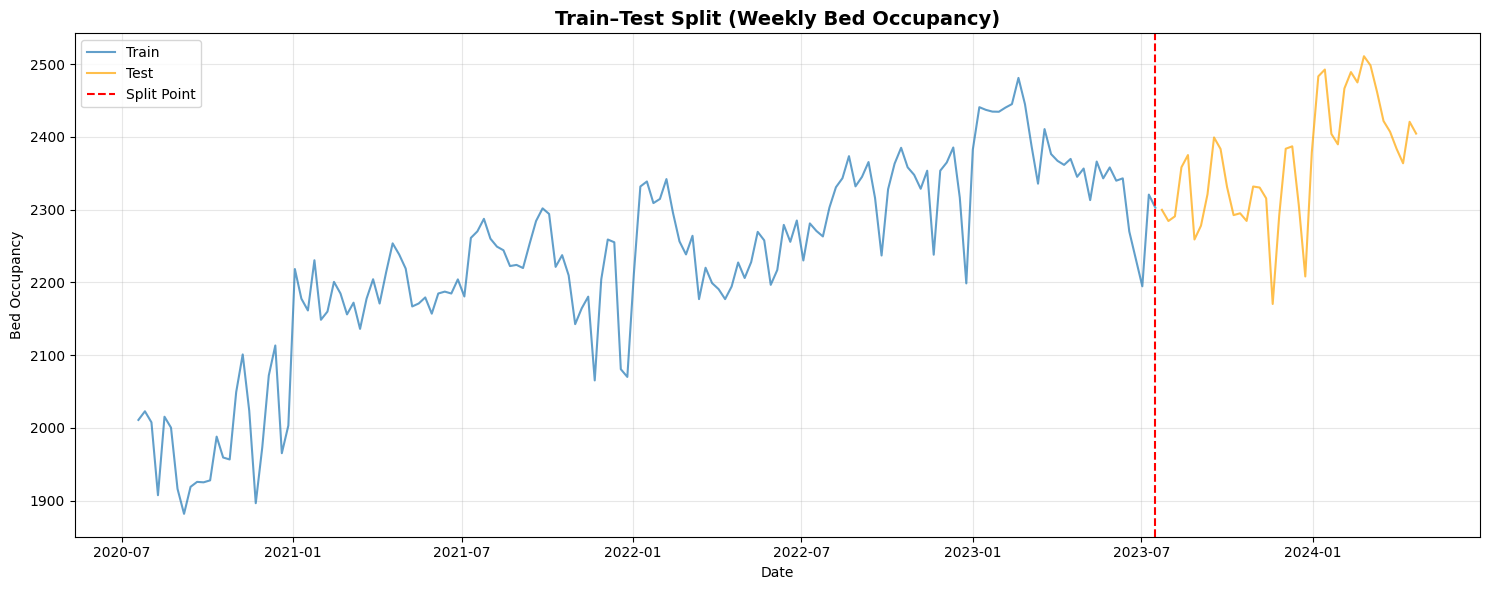

In [16]:
if len(target_series) > 0:
    train_size = int(len(target_series) * TRAIN_TEST_SPLIT)
    train_y = target_series.iloc[:train_size].copy()
    test_y = target_series.iloc[train_size:].copy()

    print(f"\nTrain set: {len(train_y)} weeks ({train_y.index.min().date()} to {train_y.index.max().date()})")
    print(f"Test set:  {len(test_y)} weeks ({test_y.index.min().date()} to {test_y.index.max().date()})")
    print(f"Train/Test split: {len(train_y)}/{len(test_y)} = {TRAIN_TEST_SPLIT:.1%}")

    if exog_all is not None:
        train_exog = exog_all.iloc[:train_size].copy()
        test_exog = exog_all.iloc[train_size:].copy()
    else:
        train_exog = None
        test_exog = None

    plt.figure(figsize=(15, 6))
    plt.plot(train_y.index, train_y.values, label="Train", alpha=0.7, linewidth=1.5)
    plt.plot(test_y.index, test_y.values, label="Test", alpha=0.7, linewidth=1.5, color="orange")
    plt.axvline(x=train_y.index[-1], color="red", linestyle="--", label="Split Point")
    plt.title("Train–Test Split (Weekly Bed Occupancy)", fontsize=14, fontweight="bold")
    plt.xlabel("Date")
    plt.ylabel("Bed Occupancy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_plot(
        plt.gcf(),
        "ssm_train_test_split.png",
        RESULTS_PATH,
        DRIVE_RESULTS_PATH,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
else:
    train_y = pd.Series(dtype=float)
    test_y = pd.Series(dtype=float)
    train_exog = None
    test_exog = None

## Fit Structural State-Space Model (Unobserved Components)

In [17]:
print("=" * 70)
print("FITTING STRUCTURAL STATE-SPACE MODEL (UNOBSERVED COMPONENTS)")
print("=" * 70)

ssm_result = None
ssm_forecast = None

if len(train_y) > 0:
    try:
        mod = UnobservedComponents(
            endog=train_y,
            level="local linear trend",
            seasonal=WEEKS_PER_YEAR,
            exog=train_exog,
        )
        ssm_result = mod.fit(disp=False)
        print("✓ Structural model fitted successfully")
        print(ssm_result.summary())

        # Rolling Forecast with Hybrid Retraining
        if len(test_y) > 0:
            n_periods = len(test_y)
            print(f"\n  Rolling forecast with hybrid retraining for {n_periods} weeks...")
            print(f"    Window size: {SSM_WINDOW_SIZE} weeks")
            print(f"    Retraining: base={SSM_BASE_RETRAIN_FREQUENCY} weeks, error threshold={SSM_ERROR_THRESHOLD}x, min interval={SSM_EARLY_RETRAIN_THRESHOLD} weeks")

            # Initialize tracking
            all_forecasts = []
            current_train_y = train_y.copy()
            current_train_exog = train_exog.copy() if train_exog is not None else None
            current_model = ssm_result
            weeks_since_retrain = 0
            forecast_errors = []
            historical_avg_error = None
            min_windows_for_avg = 3
            retrain_count = 0

            # Rolling forecast loop
            from tqdm import tqdm

            for start_idx in tqdm(range(0, n_periods, SSM_WINDOW_SIZE), desc="    SSM forecasting", unit="window"):
                end_idx = min(start_idx + SSM_WINDOW_SIZE, n_periods)
                horizon = end_idx - start_idx

                # Check for hybrid retraining
                should_retrain = False
                retrain_reason = None

                # Time-based retraining
                if SSM_BASE_RETRAIN_FREQUENCY > 0 and weeks_since_retrain >= SSM_BASE_RETRAIN_FREQUENCY:
                    should_retrain = True
                    retrain_reason = "time-based"

                # Error-based retraining
                if (historical_avg_error is not None and
                    len(forecast_errors) > 0 and
                    weeks_since_retrain >= SSM_EARLY_RETRAIN_THRESHOLD):
                    recent_error = forecast_errors[-1]
                    if recent_error > historical_avg_error * SSM_ERROR_THRESHOLD:
                        should_retrain = True
                        retrain_reason = f"error ({recent_error:.2f} > {historical_avg_error * SSM_ERROR_THRESHOLD:.2f})"

                # Perform retraining if needed
                if should_retrain and start_idx > 0:
                    try:
                        new_mod = UnobservedComponents(
                            endog=current_train_y,
                            level="local linear trend",
                            seasonal=WEEKS_PER_YEAR,
                            exog=current_train_exog,
                        )
                        current_model = new_mod.fit(disp=False)
                        weeks_since_retrain = 0
                        retrain_count += 1
                    except Exception:
                        pass  # Keep using current model

                # Generate forecast for this window
                try:
                    if current_train_exog is not None and test_exog is not None:
                        window_exog = test_exog.iloc[start_idx:end_idx]
                        fc_res = current_model.get_forecast(steps=horizon, exog=window_exog)
                    else:
                        fc_res = current_model.get_forecast(steps=horizon)
                    window_forecast = fc_res.predicted_mean.values
                except Exception:
                    # Fallback to last known value
                    window_forecast = np.full(horizon, current_train_y.iloc[-1])

                all_forecasts.extend(window_forecast)

                # Update training data with actual test values for next iteration
                actual_window = test_y.iloc[start_idx:end_idx]
                current_train_y = pd.concat([current_train_y, actual_window])
                if current_train_exog is not None and test_exog is not None:
                    current_train_exog = pd.concat([current_train_exog, test_exog.iloc[start_idx:end_idx]])

                # Calculate error for this window
                if len(actual_window) > 0:
                    window_error = np.mean(np.abs(actual_window.values - window_forecast[:len(actual_window)]))
                    forecast_errors.append(window_error)
                    if len(forecast_errors) >= min_windows_for_avg:
                        historical_avg_error = np.mean(forecast_errors[:-1])

                weeks_since_retrain += horizon

            # Create final forecast series
            ssm_forecast = pd.Series(all_forecasts[:n_periods], index=test_y.index)
            print(f"✓ Structural rolling forecast generated ({retrain_count} retrains)")
    except Exception as e:
        print(f"⚠️  Structural model fitting failed: {e}")
        ssm_result = None
        ssm_forecast = None
else:
    print("⚠️  Not enough training data to fit structural model.")

# Save Structural model for forecasting notebook
if ssm_result is not None:
    save_file(ssm_result, 'structural_model.pkl', MODELS_PATH, DRIVE_MODELS_PATH)
    print("✓ Structural model saved to structural_model.pkl")

FITTING STRUCTURAL STATE-SPACE MODEL (UNOBSERVED COMPONENTS)
✓ Structural model fitted successfully
                            Unobserved Components Results                            
Dep. Variable:                 bed_occupancy   No. Observations:                  157
Model:                    local linear trend   Log Likelihood                -558.221
                   + stochastic seasonal(52)   AIC                           1136.443
Date:                       Thu, 18 Dec 2025   BIC                           1162.886
Time:                               08:44:01   HQIC                          1147.156
Sample:                           07-19-2020                                         
                                - 07-16-2023                                         
Covariance Type:                         opg                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------

    SSM forecasting: 100%|██████████| 20/20 [02:39<00:00,  7.99s/window]


✓ Structural rolling forecast generated (19 retrains)
✓ Saved to local: /content/hospital_occupancy_forecasting/models/structural_model.pkl
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/models/structural_model.pkl
✓ Structural model saved to structural_model.pkl


## Model Evaluation (Train & Test) and Plots

STRUCTURAL MODEL EVALUATION

Train vs Test metrics (structural model):
Set          MAE        RMSE       MAPE (%)     Bias       n       
-------------------------------------------------------------------
Train        114.40     272.36     5.50         26.21      157     
Test         41.36      52.19      1.74         -0.99      40      
✓ Saved to local: /content/hospital_occupancy_forecasting/models/structural_evaluation.csv
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/models/structural_evaluation.csv

✓ Structural model metrics saved to structural_evaluation.csv
✓ Saved plot to local: /content/hospital_occupancy_forecasting/results/visualizations/model_development/structural_model_results.png
✓ Saved plot to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/results/visualizations/model_development/structural_model_results.png


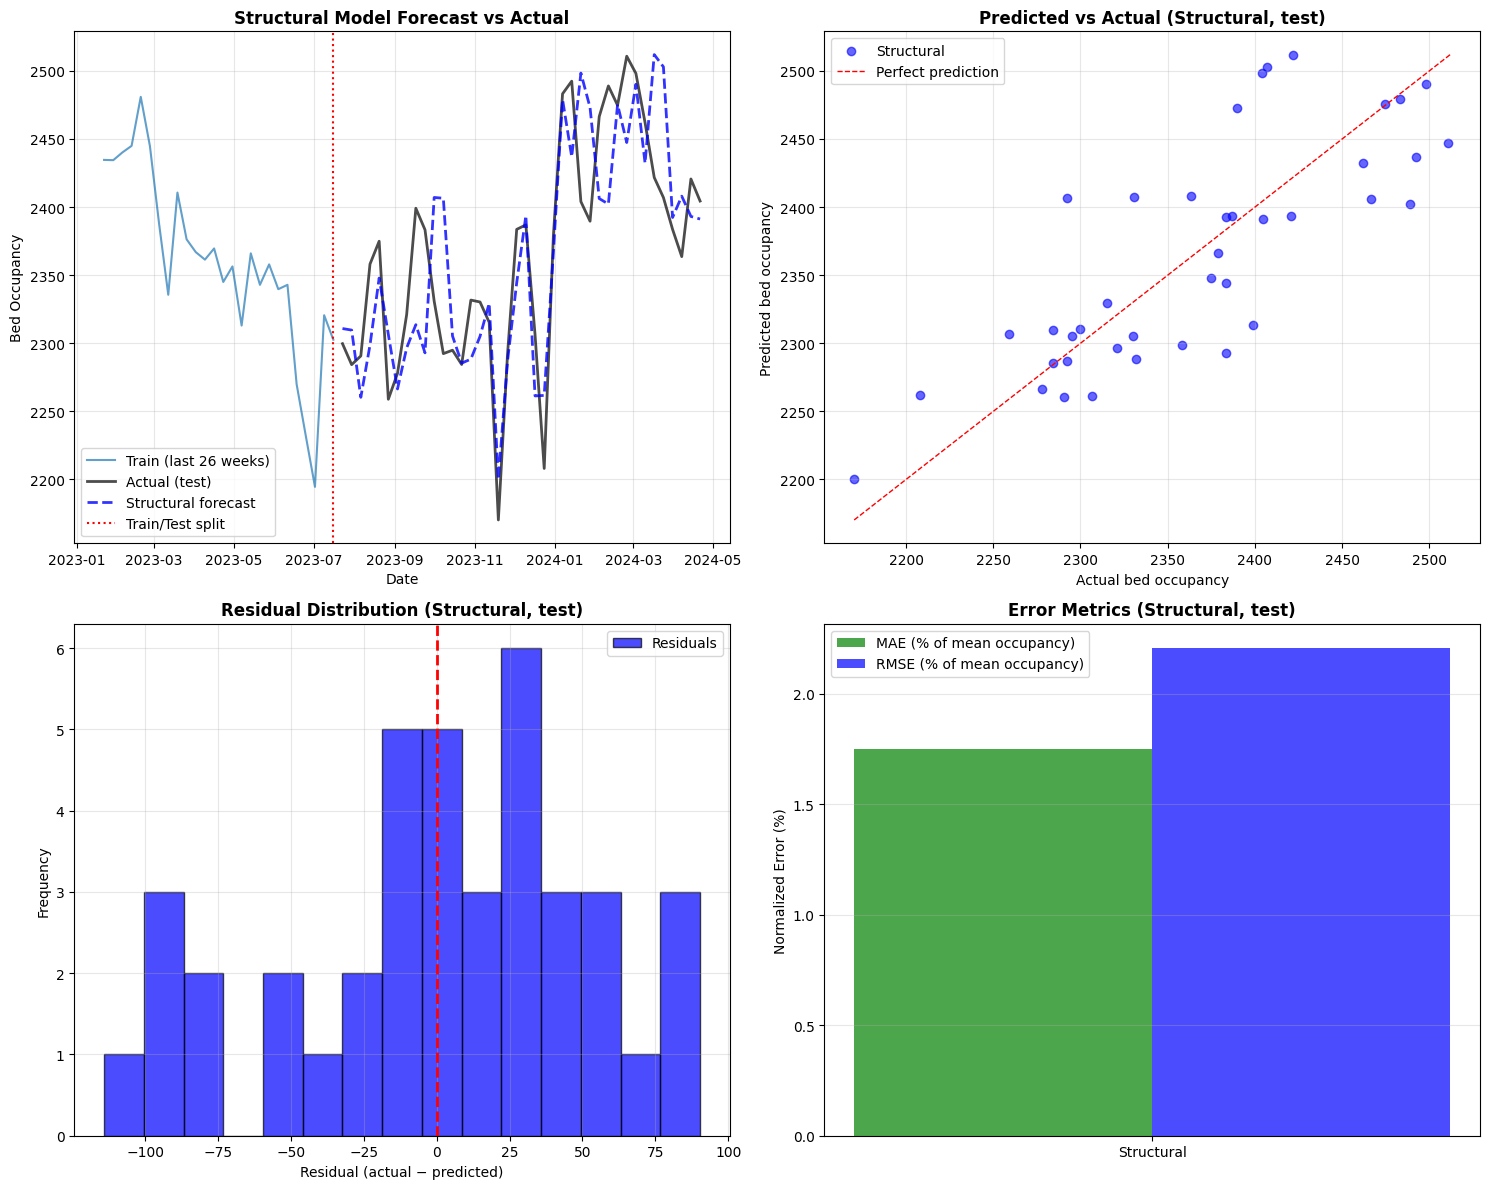

✓ Saved to local: /content/hospital_occupancy_forecasting/models/structural_forecast.csv
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_occupancy_forecasting/models/structural_forecast.csv
✓ Structural forecast DataFrame saved


In [18]:
print("=" * 70)
print("STRUCTURAL MODEL EVALUATION")
print("=" * 70)

if ssm_result is not None and ssm_forecast is not None and len(test_y) > 0:
    # Align forecast and actuals
    fc_aligned = ssm_forecast.reindex(test_y.index)
    mask = ~(fc_aligned.isna() | test_y.isna())

    if mask.sum() > 0:
        y_test_valid = test_y[mask]
        y_pred_valid = fc_aligned[mask]

        # Test metrics
        test_metrics = calculate_all_metrics(y_test_valid.values, y_pred_valid.values)
        test_metrics["n"] = int(mask.sum())

        # Training metrics (in-sample fitted values)
        train_pred_vals = ssm_result.fittedvalues
        train_pred_series = pd.Series(train_pred_vals, index=train_y.index)
        mask_tr = ~(train_pred_series.isna() | train_y.isna())
        if mask_tr.sum() > 0:
            train_metrics = calculate_all_metrics(
                train_y[mask_tr].values, train_pred_series[mask_tr].values
            )
            train_metrics["n"] = int(mask_tr.sum())
        else:
            train_metrics = {k: np.nan for k in ["RMSE", "MAE", "MAPE", "Bias"]}
            train_metrics["n"] = 0

        print("\nTrain vs Test metrics (structural model):")
        header = f"{'Set':<12} {'MAE':<10} {'RMSE':<10} {'MAPE (%)':<12} {'Bias':<10} {'n':<8}"
        print(header)
        print("-" * len(header))

        def _fmt_row(name, m):
            mae_val = m.get("MAE", np.nan)
            rmse_val = m.get("RMSE", np.nan)
            mape_val = m.get("MAPE", np.nan)
            bias_val = m.get("Bias", np.nan)
            n_val = int(m.get("n", 0))
            mape_str = f"{mape_val:.2f}" if not np.isnan(mape_val) else "N/A"
            print(
                f"{name:<12} {mae_val:<10.2f} {rmse_val:<10.2f} "
                f"{mape_str:<12} {bias_val:<10.2f} {n_val:<8d}"
            )

        _fmt_row("Train", train_metrics)
        _fmt_row("Test", test_metrics)

        # Save metrics to CSV
        metrics_df = pd.DataFrame(
            {
                "structural_train": train_metrics,
                "structural_test": test_metrics,
            }
        ).T
        save_file(metrics_df, "structural_evaluation.csv", MODELS_PATH, DRIVE_MODELS_PATH)
        print("\n✓ Structural model metrics saved to structural_evaluation.csv")

        # Plots
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        # Plot 1: Forecast vs actual
        ax1 = axes[0, 0]
        train_display = min(26, len(train_y))
        ax1.plot(
            train_y.index[-train_display:],
            train_y.values[-train_display:],
            label=f"Train (last {train_display} weeks)",
            alpha=0.7,
            linewidth=1.5,
        )
        ax1.plot(
            test_y.index,
            test_y.values,
            label="Actual (test)",
            alpha=0.7,
            color="black",
            linewidth=2,
        )
        ax1.plot(
            y_pred_valid.index,
            y_pred_valid.values,
            label="Structural forecast",
            alpha=0.8,
            linestyle="--",
            color="blue",
            linewidth=2,
        )
        ax1.axvline(
            x=train_y.index[-1], color="red", linestyle=":", label="Train/Test split"
        )
        ax1.set_title("Structural Model Forecast vs Actual", fontweight="bold")
        ax1.set_xlabel("Date")
        ax1.set_ylabel("Bed Occupancy")
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Plot 2: Predicted vs actual scatter
        ax2 = axes[0, 1]
        r2_val = test_metrics.get("R2", np.nan)
        label = (
            f"Structural (R²={r2_val:.4f})"
            if not np.isnan(r2_val)
            else "Structural"
        )
        ax2.scatter(
            y_test_valid.values,
            y_pred_valid.values,
            alpha=0.6,
            color="blue",
            label=label,
        )
        min_val = min(y_test_valid.min(), y_pred_valid.min())
        max_val = max(y_test_valid.max(), y_pred_valid.max())
        ax2.plot(
            [min_val, max_val],
            [min_val, max_val],
            "r--",
            label="Perfect prediction",
            linewidth=1,
        )
        ax2.set_title("Predicted vs Actual (Structural, test)", fontweight="bold")
        ax2.set_xlabel("Actual bed occupancy")
        ax2.set_ylabel("Predicted bed occupancy")
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # Plot 3: Residual distribution
        ax3 = axes[1, 0]
        residuals = y_test_valid.values - y_pred_valid.values
        ax3.hist(
            residuals,
            bins=15,
            alpha=0.7,
            color="blue",
            edgecolor="black",
            label="Residuals",
        )
        ax3.axvline(x=0, color="r", linestyle="--", linewidth=2)
        ax3.set_title("Residual Distribution (Structural, test)", fontweight="bold")
        ax3.set_xlabel("Residual (actual − predicted)")
        ax3.set_ylabel("Frequency")
        ax3.legend()
        ax3.grid(True, alpha=0.3)

        # Plot 4: Normalized MAE/RMSE
        ax4 = axes[1, 1]
        mean_actual = y_test_valid.mean()
        mae_norm = (
            test_metrics["MAE"] / mean_actual * 100 if mean_actual != 0 else np.nan
        )
        rmse_norm = (
            test_metrics["RMSE"] / mean_actual * 100 if mean_actual != 0 else np.nan
        )
        x_pos = np.arange(1)
        width = 0.35
        ax4.bar(
            x_pos - width / 2,
            [mae_norm],
            width,
            label="MAE (% of mean occupancy)",
            alpha=0.7,
            color="green",
        )
        ax4.bar(
            x_pos + width / 2,
            [rmse_norm],
            width,
            label="RMSE (% of mean occupancy)",
            alpha=0.7,
            color="blue",
        )
        ax4.set_xticks(x_pos)
        ax4.set_xticklabels(["Structural"])
        ax4.set_ylabel("Normalized Error (%)")
        ax4.set_title("Error Metrics (Structural, test)", fontweight="bold")
        ax4.legend()
        ax4.grid(True, alpha=0.3, axis="y")

        plt.tight_layout()
        save_plot(
            plt.gcf(),
            "structural_model_results.png",
            RESULTS_PATH,
            DRIVE_RESULTS_PATH,
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

        # Save forecast DataFrame
        structural_forecast_df = pd.DataFrame(
            {
                "actual": test_y.reindex(fc_aligned.index).values,
                "predicted": fc_aligned.values,
            },
            index=fc_aligned.index,
        )
        save_file(
            structural_forecast_df,
            "structural_forecast.csv",
            MODELS_PATH,
            DRIVE_MODELS_PATH,
        )
        print("✓ Structural forecast DataFrame saved")
    else:
        print("⚠️  No valid overlap between structural forecast and test data for evaluation")
else:
    print("⚠️  Structural model not trained or no test data - cannot evaluate")

## Summary

- Trained a **structural state-space model** (local linear trend + 52-week seasonality)
  for weekly bed occupancy, with curated exogenous regressors from the centralized
  ARIMAX feature configuration.
- Computed **train and test metrics** and saved them to `structural_evaluation.csv`.
- Saved structural forecasts to `structural_forecast.csv` for downstream analysis
  and unified reporting in `05_model_evaluation.py`.